# 拓展 1+2：手写 Scaled Dot-Product Attention（单头 → 多头）

论文 3.2 节的公式：**Attention(Q, K, V) = softmax(QKᵀ / √d_k) V**

先用 NumPy 手写最小单头版本（随机输入），打印每一步的形状和数值，画出注意力权重热力图；再把单头拼成多头，对比各个头"看"的地方有什么不同。全程不碰 nn.MultiheadAttention。


In [31]:
import numpy as np

rng = np.random.default_rng(42)

# 随机输入：4 个 token，每个 token 是 8 维向量
X = rng.normal(0, 1, size=(4, 8))
print("输入 X:", X.shape, "-> (token 数, 特征维度)")
print(np.round(X, 3))


输入 X: (4, 8) -> (token 数, 特征维度)
[[ 0.305 -1.04   0.75   0.941 -1.951 -1.302  0.128 -0.316]
 [-0.017 -0.853  0.879  0.778  0.066  1.127  0.468 -0.859]
 [ 0.369 -0.959  0.878 -0.05  -0.185 -0.681  1.223 -0.155]
 [-0.428 -0.352  0.532  0.365  0.413  0.431  2.142 -0.406]]


## 单头：第一步，生成 Q、K、V

Q（Query，查询）、K（Key，键）、V（Value，值）都从**同一个 X** 经过三个**不同的线性变换**得到（这就是 Self-Attention 的"自"：一个序列自己找自己内部的关系）。做线性变换的意义：给每个角色分配可学习的权重，而不是直接用原始向量。


In [32]:
d_model = 8      # 输入维度
d_k = 8          # 单头时 Q/K 的维度

Wq = rng.normal(0, 0.5, size=(d_model, d_k))
Wk = rng.normal(0, 0.5, size=(d_model, d_k))
Wv = rng.normal(0, 0.5, size=(d_model, d_k))

Q = X @ Wq    # (4, 8)
K = X @ Wk    # (4, 8)
V = X @ Wv    # (4, 8)
print("Q:", Q.shape, " K:", K.shape, " V:", V.shape)


Q: (4, 8)  K: (4, 8)  V: (4, 8)


## 第二步，算分数：QKᵀ

Q 的每一行是一个 token 的"查询"，K 的每一行是一个 token 的"键"。QKᵀ 的第 i 行第 j 列 = 第 i 个 token 的查询和第 j 个 token 的键的点积——**点积越大，说明第 i 个 token 越关注第 j 个 token**。


In [33]:
scores = Q @ K.T            # (4, 4)
print("原始分数 scores:")
print(np.round(scores, 3))


原始分数 scores:
[[ 2.539 -0.414 -1.006 -4.508]
 [ 2.426 -0.459 -1.073 -2.476]
 [-3.016 -0.289 -0.448 -1.565]
 [ 1.504 -2.074  1.034 -2.471]]


## 第三步，除以 √d_k 再 softmax

为什么要除以 √d_k：维度越大，点积的数值天然越大（是 d_k 个乘积的累加），softmax 会被推向只有 1 和 0 的极端，梯度接近 0。除以 √d_k 把分数拉回稳定范围——所以叫 **Scaled** Dot-Product。

softmax 把每一行分数变成**和为 1 的权重分布**：每一行就是一个 token 对全部 4 个 token 的关注度分配。


In [34]:
def softmax(x):
    e = np.exp(x - x.max(axis=-1, keepdims=True))   # 减最大值防溢出，结果不变
    return e / e.sum(axis=-1, keepdims=True)

scaled = scores / np.sqrt(d_k)
weights = softmax(scaled)          # (4, 4) 每行和为 1
print("缩放后分数:")
print(np.round(scaled, 3))
print("\n注意力权重（每行和为 1）:")
print(np.round(weights, 3))
print("\n每行求和验证:", weights.sum(axis=-1))


缩放后分数:
[[ 0.898 -0.147 -0.356 -1.594]
 [ 0.858 -0.162 -0.379 -0.875]
 [-1.066 -0.102 -0.158 -0.553]
 [ 0.532 -0.733  0.366 -0.873]]

注意力权重（每行和为 1）:
[[0.581 0.205 0.166 0.048]
 [0.547 0.197 0.159 0.097]
 [0.129 0.337 0.319 0.215]
 [0.421 0.119 0.357 0.103]]

每行求和验证: [1. 1. 1. 1.]


## 第四步，加权求和 V，并画热力图

输出 = 权重 @ V：每个 token 的新表示 = 按关注度把所有 token 的 V 加权混合。


输出: (4, 8)
[[ 0.541 -1.058  1.407 -0.494  0.655  1.239  1.315  1.258]
 [ 0.496 -0.971  1.354 -0.54   0.605  1.178  1.224  1.249]
 [ 0.23  -0.166  0.939 -0.763  0.33   0.653  0.518  1.067]
 [ 0.332 -0.999  1.34  -0.707  0.873  0.927  1.068  1.359]]


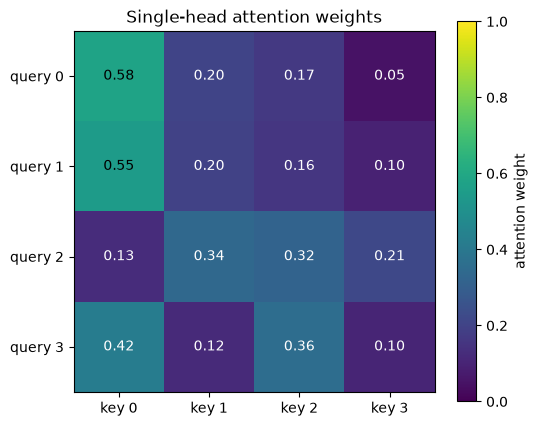

saved: attn-single-head.png


In [35]:
output = weights @ V          # (4, 8)
print("输出:", output.shape)
print(np.round(output, 3))

import matplotlib.pyplot as plt

plt.figure(figsize=(5.5, 4.5))
plt.imshow(weights, cmap="viridis", vmin=0, vmax=1)
plt.colorbar(label="attention weight")
plt.xticks(range(4), [f"key {i}" for i in range(4)])
plt.yticks(range(4), [f"query {i}" for i in range(4)])
for i in range(4):
    for j in range(4):
        plt.text(j, i, f"{weights[i, j]:.2f}", ha="center", va="center",
                 color="white" if weights[i, j] < 0.5 else "black")
plt.title("Single-head attention weights")
plt.tight_layout()
plt.savefig("attn-single-head.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved: attn-single-head.png")


## 拓展 2：多头注意力

论文的做法：把 d_model 切成 h 份，每头在更小的维度（d_k = d_model / h）上各自做注意力，最后拼回来再线性变换一次。

**多头不是简单重复**：每头有自己独立的 Wq/Wk/Wv，随机初始化让各头落入不同的子空间——有的头盯邻近词，有的头抓长距离依赖，有的头跟语法结构。单头只有一个注意力分布，多头等于从多个角度同时看一遍序列，再把视角拼起来。


In [36]:
n_heads = 8   # 论文 base 版 h=8，d_model=512 时每头 d_k=64；这里 d_model=8、每头 2 维，比例同构
d_head = d_model // n_heads    # 每头 2 维

# 每头独立的投影矩阵，形状 (d_model, d_head)
Wqs = [rng.normal(0, 0.5, size=(d_model, d_head)) for _ in range(n_heads)]
Wks = [rng.normal(0, 0.5, size=(d_model, d_head)) for _ in range(n_heads)]
Wvs = [rng.normal(0, 0.5, size=(d_model, d_head)) for _ in range(n_heads)]
Wo = rng.normal(0, 0.5, size=(d_model, d_model))   # 拼接后的输出投影

head_weights = []
head_outputs = []
for h in range(n_heads):
    Qh = X @ Wqs[h]                       # (4, 2)
    Kh = X @ Wks[h]                       # (4, 2)
    Vh = X @ Wvs[h]                       # (4, 2)
    wh = softmax(Qh @ Kh.T / np.sqrt(d_head))   # (4, 4)
    head_weights.append(wh)
    head_outputs.append(wh @ Vh)          # (4, 2)
    print(f"head {h} 权重（d_k={d_head}）:")
    print(np.round(wh, 3))

concat = np.concatenate(head_outputs, axis=-1)   # (4, 8) 4 个头拼回来
output_mh = concat @ Wo                          # (4, 8) 输出投影
print("\n多头输出:", output_mh.shape)


head 0 权重（d_k=1）:
[[0.3   0.003 0.65  0.047]
 [0.337 0.028 0.509 0.126]
 [0.285 0.172 0.309 0.234]
 [0.144 0.503 0.117 0.236]]
head 1 权重（d_k=1）:
[[0.098 0.088 0.355 0.459]
 [0.398 0.456 0.084 0.062]
 [0.392 0.445 0.094 0.07 ]
 [0.421 0.527 0.033 0.02 ]]
head 2 权重（d_k=1）:
[[0.956 0.    0.043 0.   ]
 [0.955 0.    0.045 0.   ]
 [0.78  0.021 0.182 0.017]
 [0.866 0.006 0.122 0.005]]
head 3 权重（d_k=1）:
[[0.251 0.263 0.236 0.25 ]
 [0.251 0.307 0.195 0.247]
 [0.23  0.153 0.38  0.236]
 [0.248 0.345 0.165 0.242]]
head 4 权重（d_k=1）:
[[0.234 0.278 0.246 0.243]
 [0.316 0.156 0.257 0.271]
 [0.138 0.482 0.199 0.181]
 [0.263 0.229 0.253 0.255]]
head 5 权重（d_k=1）:
[[0.16  0.273 0.261 0.306]
 [0.131 0.279 0.261 0.328]
 [0.091 0.286 0.259 0.364]
 [0.07  0.288 0.254 0.388]]
head 6 权重（d_k=1）:
[[0.793 0.088 0.068 0.051]
 [0.097 0.266 0.298 0.34 ]
 [0.648 0.139 0.117 0.096]
 [0.715 0.116 0.095 0.075]]
head 7 权重（d_k=1）:
[[0.781 0.175 0.038 0.006]
 [0.479 0.279 0.16  0.082]
 [0.612 0.253 0.102 0.034]
 [0.351 0.27

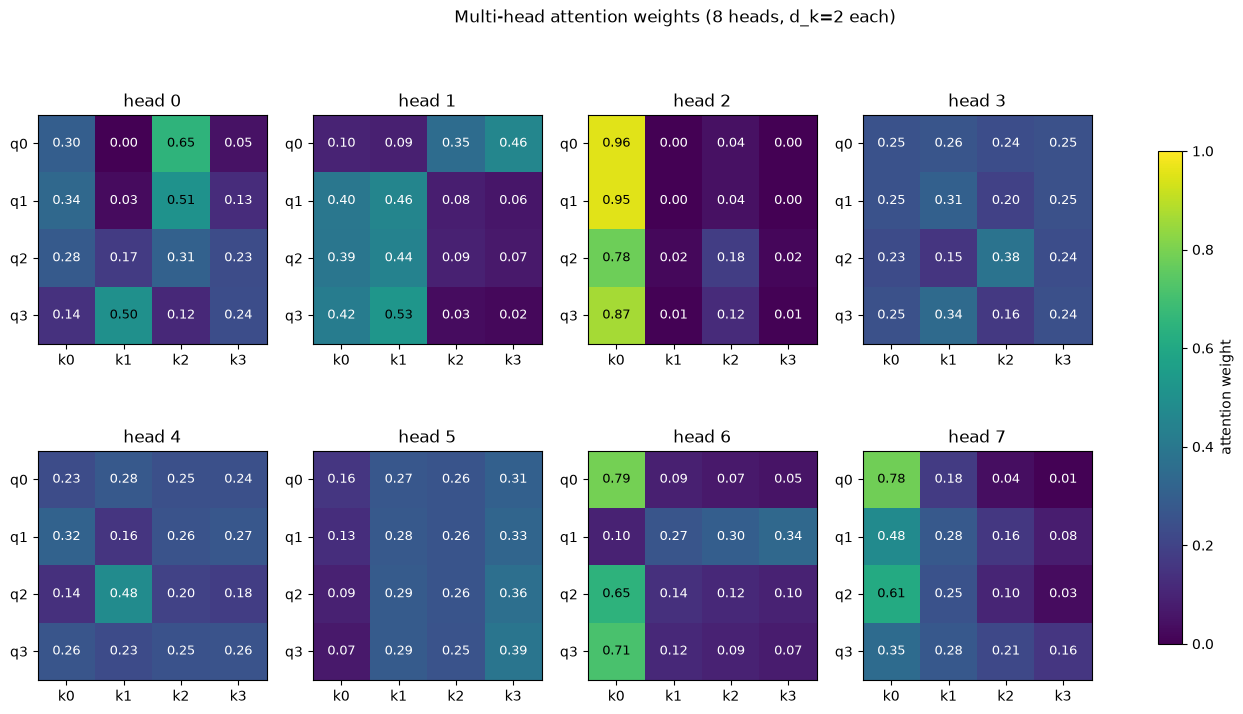

saved: attn-multi-head.png


In [37]:
fig, axes = plt.subplots(2, 4, figsize=(17, 8))
for h in range(n_heads):
    ax = axes[h // 4, h % 4]
    im = ax.imshow(head_weights[h], cmap="viridis", vmin=0, vmax=1)
    ax.set_title(f"head {h}")
    ax.set_xticks(range(4)); ax.set_xticklabels([f"k{i}" for i in range(4)])
    ax.set_yticks(range(4)); ax.set_yticklabels([f"q{i}" for i in range(4)])
    for i in range(4):
        for j in range(4):
            ax.text(j, i, f"{head_weights[h][i, j]:.2f}", ha="center", va="center",
                    color="white" if head_weights[h][i, j] < 0.5 else "black", fontsize=9)
fig.colorbar(im, ax=axes, shrink=0.8, label="attention weight")
fig.suptitle("Multi-head attention weights (8 heads, d_k=2 each)")
plt.savefig("attn-multi-head.png", dpi=150, bbox_inches="tight")
plt.show()
print("saved: attn-multi-head.png")


## 单头 vs 多头小结

| | 单头 | 多头（8 头，同论文 base h=8） |
|---|---|---|
| Q/K 维度 | 8 | 每头 2 |
| 注意力分布 | 1 个 | 8 个不同视角 |
| 总计算量 | 相近（d_model 切分） | 相近（每头变小） |

各头的权重矩阵数值差异明显——不同的初始化让每头各自学到不同的"关注模式"，这正是"多头不是重复劳动"的直接证据。

## 与 nn.MultiheadAttention 对齐验证（只对数值，不调它算注意力）

用 PyTorch 的 nn.MultiheadAttention 加载我们手写的同一套权重，确认输出一致——证明手写实现是对的：


In [38]:
import torch
import torch.nn as nn

# PyTorch nn.MultiheadAttention 的权重布局与手写版有两处约定差异，正好用来理解内部实现：
#   ① 输入布局：batch_first=True 时输入才是 (batch, seq, embed)；
#   ② 权重左乘：PyTorch 内部算 x @ W.T，且 head h 用 W 的第 h 段行块（转置后），
#      所以 Wq_big[h*2:(h+1)*2, :] = Wqs[h].T；out_proj 同理要放 Wo.T。
mha = nn.MultiheadAttention(embed_dim=d_model, num_heads=n_heads, bias=False, dtype=torch.float64, batch_first=True)

Wq_big = np.concatenate([W.T for W in Wqs], axis=0)   # (8, 8) 每头投影转置后按行块叠放
Wk_big = np.concatenate([W.T for W in Wks], axis=0)
Wv_big = np.concatenate([W.T for W in Wvs], axis=0)
with torch.no_grad():
    mha.in_proj_weight.copy_(torch.tensor(np.concatenate([Wq_big, Wk_big, Wv_big], axis=0)))
    mha.out_proj.weight.copy_(torch.tensor(Wo.T))

tX = torch.tensor(X).unsqueeze(0)     # (1, 4, 8) batch_first 布局
out_pt, _ = mha(tX, tX, tX)
diff = np.abs(out_pt.detach().numpy()[0] - output_mh).max()
print(f"手写多头输出 vs nn.MultiheadAttention 最大误差: {diff:.2e}")
print("一致:", diff < 1e-10)


手写多头输出 vs nn.MultiheadAttention 最大误差: 5.55e-16
一致: True
